# Helper Functions

In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/home/danilach/mipt-stats/SberTs')

%load_ext autoreload
%autoreload 2

from utils.models import DummyConditionalModel, VARModel
from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

In [2]:
import numpy as np
from collections import defaultdict
from typing import List, Dict, Any, Type
import pandas as pd
import itertools

import pmdarima as pm
from pathlib import Path
import os


def _calculate_mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan

    y_true_safe = y_true[non_zero_mask]
    y_pred_safe = y_pred[non_zero_mask]

    return np.mean(np.abs((y_true_safe - y_pred_safe) / y_true_safe)) * 100


def cross_validate_model(
    model_class: Type,
    df: pd.DataFrame,
    horizon: int,
    stride: int,
    start_window: int,
    target_columns: List[str],
    model_params: Dict[str, Any],
) -> Dict[str, List[float]]:
    errors = defaultdict(list)
    max_train_end_index = len(df) - horizon
    current_train_end_index = start_window

    fold_count = 0
    while current_train_end_index <= max_train_end_index:
        fold_count += 1

        df_train = df.iloc[:current_train_end_index]

        model = model_class(df_train, **model_params)

        for conditioning_col in target_columns:
            conditioning_idx = current_train_end_index + horizon - 1
            conditioning_val = df.loc[df.index[conditioning_idx], conditioning_col]

            predicted_cols, predicted_series = model.make_prediction(
                horizon=horizon, columns=[conditioning_col], values=[conditioning_val]
            )

            for i, pred_col in enumerate(predicted_cols):
                start_val_idx = current_train_end_index
                end_val_idx = current_train_end_index + horizon
                actual_vals = df[pred_col].iloc[start_val_idx:end_val_idx].values

                predicted_vals = predicted_series[i]

                mape = _calculate_mape(actual_vals, predicted_vals)
                if not np.isnan(mape):
                    errors[pred_col].append(mape)

        current_train_end_index += stride

    return dict(errors)


def calc_avg_error(cv_errors):
    ans = {}
    for column, error_list in cv_errors.items():
        avg_mape = np.mean(error_list)
        ans[column] = avg_mape

    return ans


def build_error_matrix(
    model_class: Type,
    df: pd.DataFrame,
    horizon: int,
    stride: int,
    start_window: int,
    model_params: Dict[str, Any],
) -> pd.DataFrame:
    all_columns = df.columns.tolist()

    error_matrix = pd.DataFrame(index=all_columns, columns=all_columns, dtype=float)
    error_matrix.index.name = "Conditioning Variable"
    error_matrix.columns.name = "Predicted Variable"

    for conditioning_col in all_columns:
        cv_errors = cross_validate_model(
            model_class=model_class,
            df=df,
            horizon=horizon,
            stride=stride,
            start_window=start_window,
            target_columns=[conditioning_col],
            model_params=model_params,
        )

        avg_errors = calc_avg_error(cv_errors)

        for predicted_col, avg_error in avg_errors.items():
            error_matrix.loc[conditioning_col, predicted_col] = avg_error

    return error_matrix


def build_short_error_matrix(
    model_class: Type,
    df: pd.DataFrame,
    horizon: int,
    stride: int,
    start_window: int,
    model_params: Dict[str, Any],
) -> pd.DataFrame:

    all_columns = df.columns.tolist()

    error_matrix = pd.DataFrame(index=all_columns, columns=all_columns, dtype=float)
    error_matrix.index.name = "Conditioning Variable"
    error_matrix.columns.name = "Predicted Variable"

    avg_errors = 0
    for conditioning_col in all_columns[:1]:
        cv_errors = cross_validate_model(
            model_class=model_class,
            df=df,
            horizon=horizon,
            stride=stride,
            start_window=start_window,
            target_columns=[conditioning_col],
            model_params=model_params,
        )

        avg_errors = calc_avg_error(cv_errors)

        for predicted_col, avg_error in avg_errors.items():
            error_matrix.loc[conditioning_col, predicted_col] = avg_error

    for conditioning_col in all_columns[1:]:
        for predicted_col, avg_error in avg_errors.items():
            error_matrix.loc[conditioning_col, predicted_col] = avg_error

    return error_matrix

# Model

In [ ]:
from sktime.forecasting.neuralforecast import NeuralForecastLSTM
from neuralforecast.models import LSTM



In [ ]:
from neuralforecast.utils import AirPassengersPanel, AirPassengersStatic


In [ ]:
from utils.models import SimpleVECM

# Chemicals

In [10]:
data_path = "/home/danilach/mipt-stats/SberTs/Data/chemicals_nona.csv"
df = pd.read_csv(data_path, index_col=0)
df.index = pd.to_datetime(df.index)

In [13]:
df_long = df.melt(var_name="unique_id", value_name="y", ignore_index=False)
df_long = df_long.reset_index().rename(columns={"index": "ds"})

In [ ]:
param_grid = {
    "k_ar_diff": [1, 2, 3],
    "coint_rank": [1, 2, 3],
    "deterministic": ["n", "co", "ci"],
    "freq": ["MS"]
}

param_keys = list(param_grid.keys())
param_combinations = list(itertools.product(*param_grid.values()))
best_metric = float("inf")
best_params = None
best_horizon = None
best_err_mat = None
horizon_list = [12]
stride = 4
start_window = 60
model_class = SimpleVECM


for combo in param_combinations:
    model_params = dict(zip(param_keys, combo))
    err_mat = build_short_error_matrix(
        model_class=model_class,
        df=df,
        horizon=12,
        stride=stride,
        start_window=start_window,
        model_params=model_params,
    )
    metric = np.mean(err_mat)
    if metric < best_metric:
        best_metric = metric
        best_params = model_params.copy()
        best_err_mat = err_mat.copy()

print(f"New best metric: {best_metric:.4f}")
print(f"Best params: {best_params}")

In [ ]:
matrix_params = {
    "model_class": SimpleVECM,
    "df": df,
    "horizon": 12,
    "stride": 4,
    "start_window": 60,
    "model_params": {
        "k_ar_diff": 2,
        "coint_rank": 1,
        "deterministic": "ci",
        "freq": "MS"
    },
}
horizon_list = [12, 24, 36, 48]


for horizon in horizon_list:
    matrix_params["horizon"] = horizon
    err_mat = build_error_matrix(**matrix_params)
    output_dir = "/home/danilach/mipt-stats/SberTs/results/simple_vecm_chemicals"
    os.makedirs(output_dir, exist_ok=True)
    output_path = (
        f"{output_dir}/err_mat_{horizon}_{matrix_params["model_params"].values()}.csv"
    )
    err_mat.to_csv(output_path, index=True)

### Матрицы

38.885167233961546


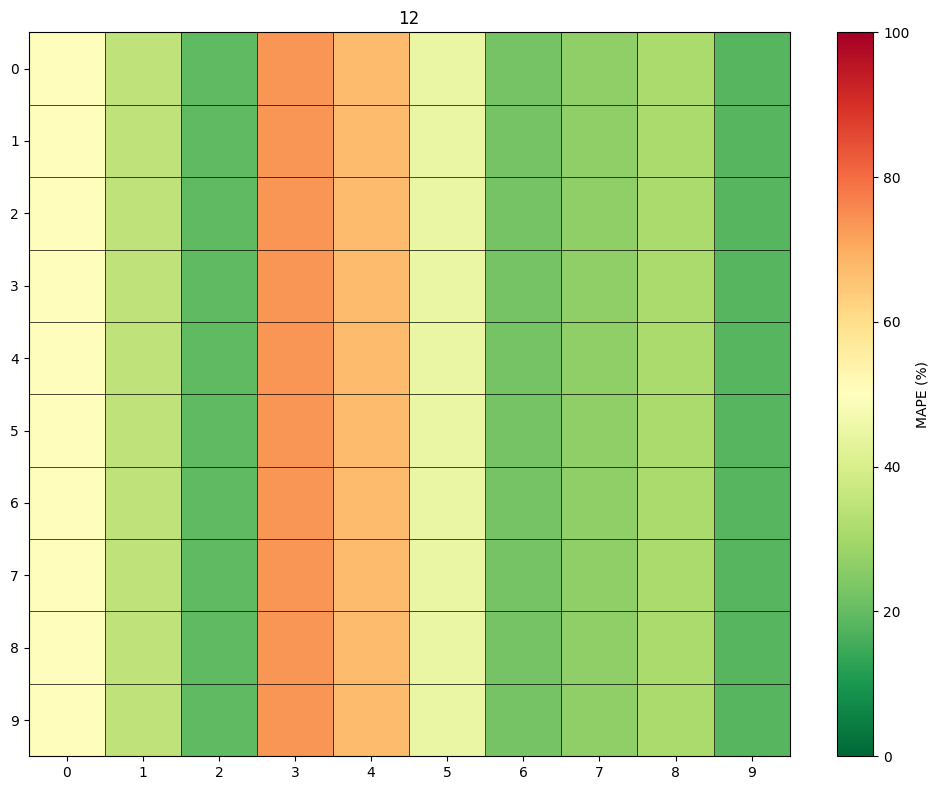

123.08926735653594


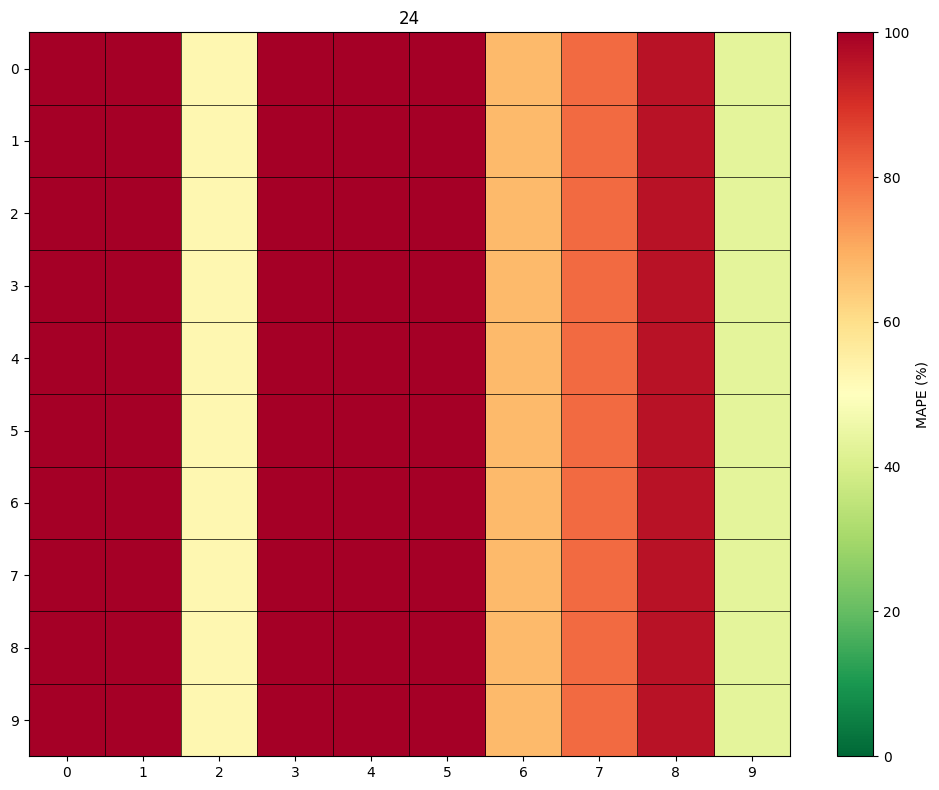

350.99149981557713


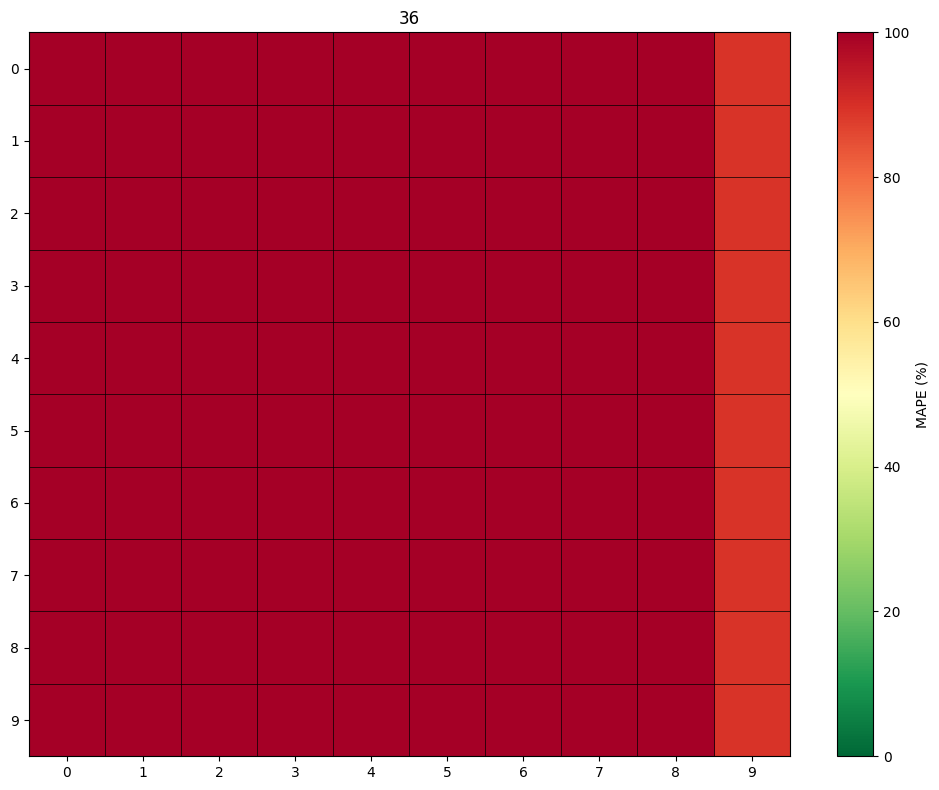

66.2358279258947


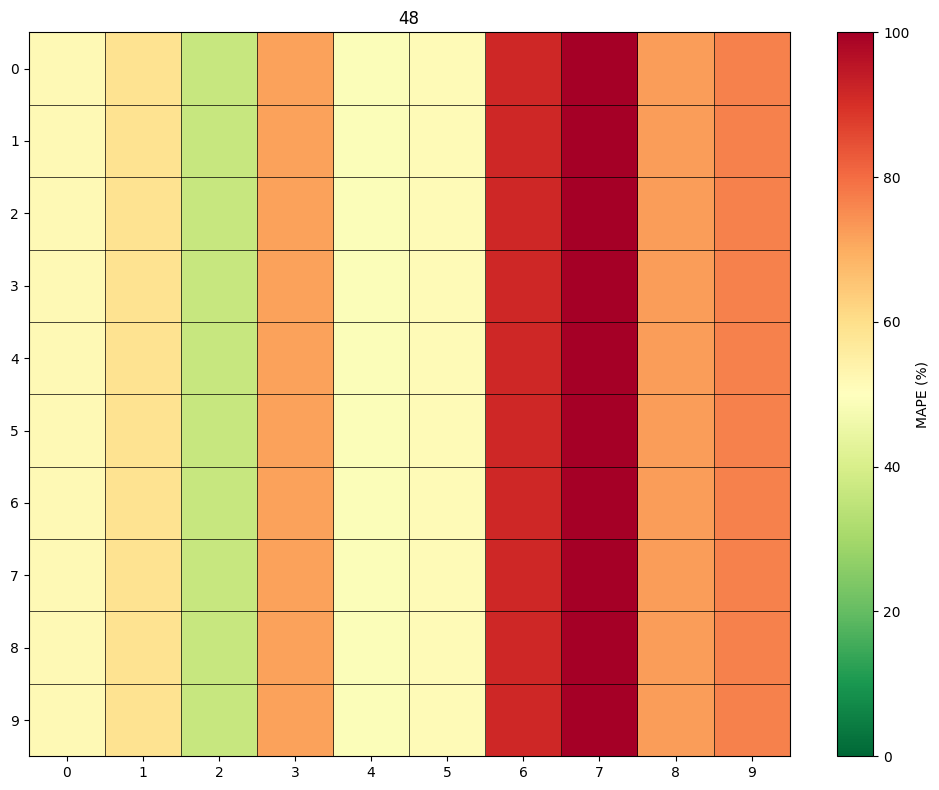

In [16]:
for horizon in horizon_list:
    file_path = f"/home/danilach/mipt-stats/SberTs/results/simple_vecm_chemicals/err_mat_{horizon}_dict_values([2, 1, 'ci']).csv"
    err_mat = pd.read_csv(file_path, index_col=0)
    print(np.mean(err_mat))
    plot_error_matrix(err_mat, title=f"{horizon}")

Опять наблюдаем странность что на горизонте 4 года ошибка лучше чем на горизонте 1 и куда лучше чем на горизонте 2 и 3 года

### Ряды

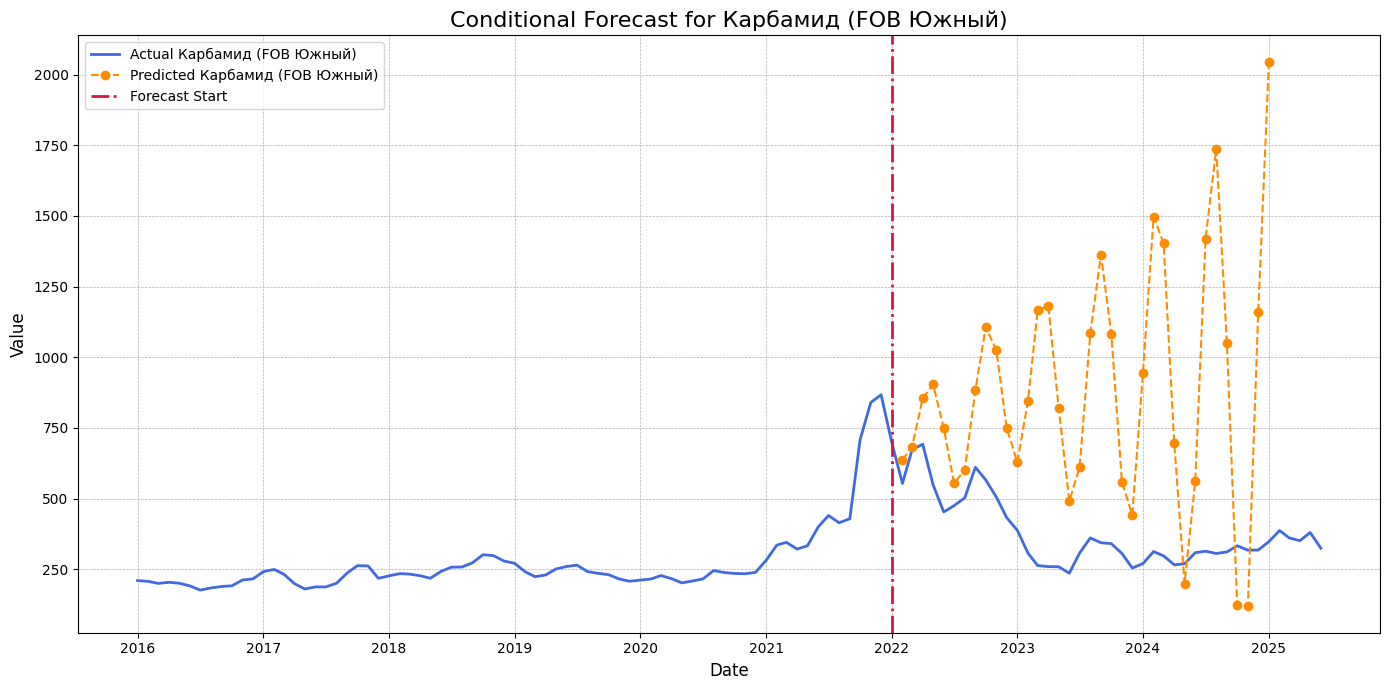

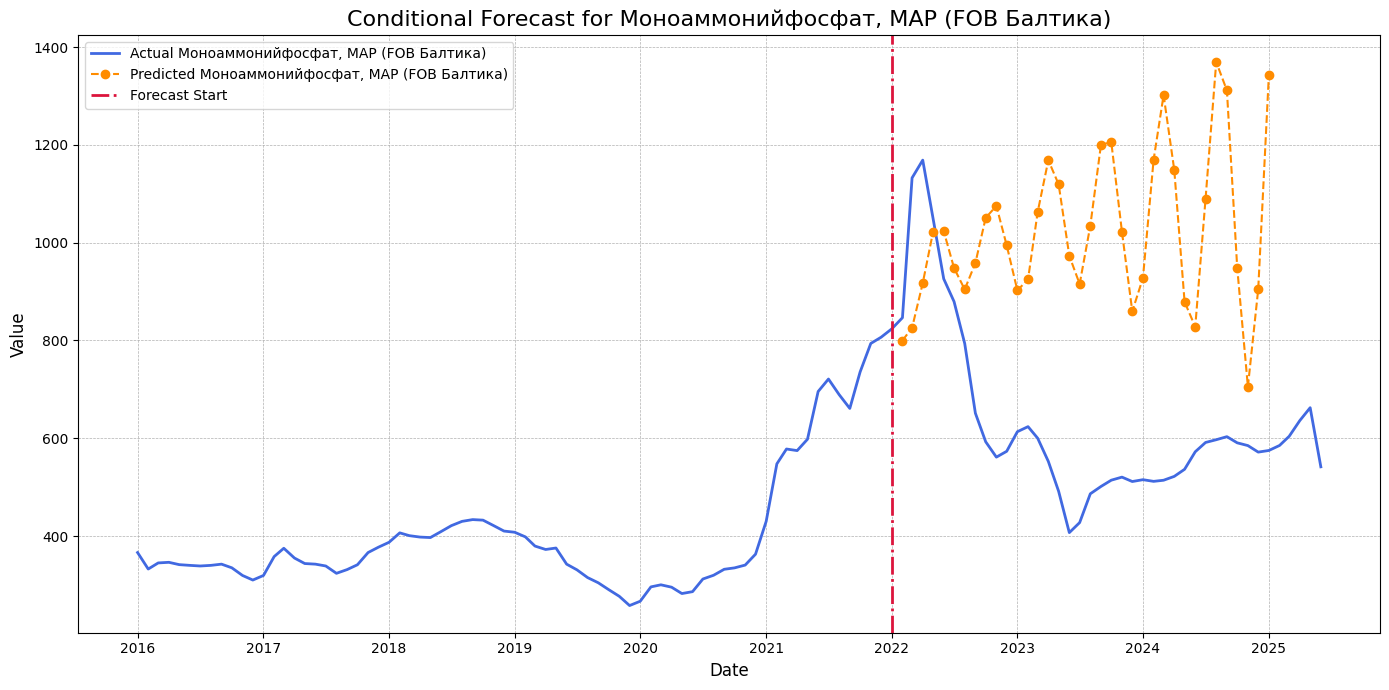

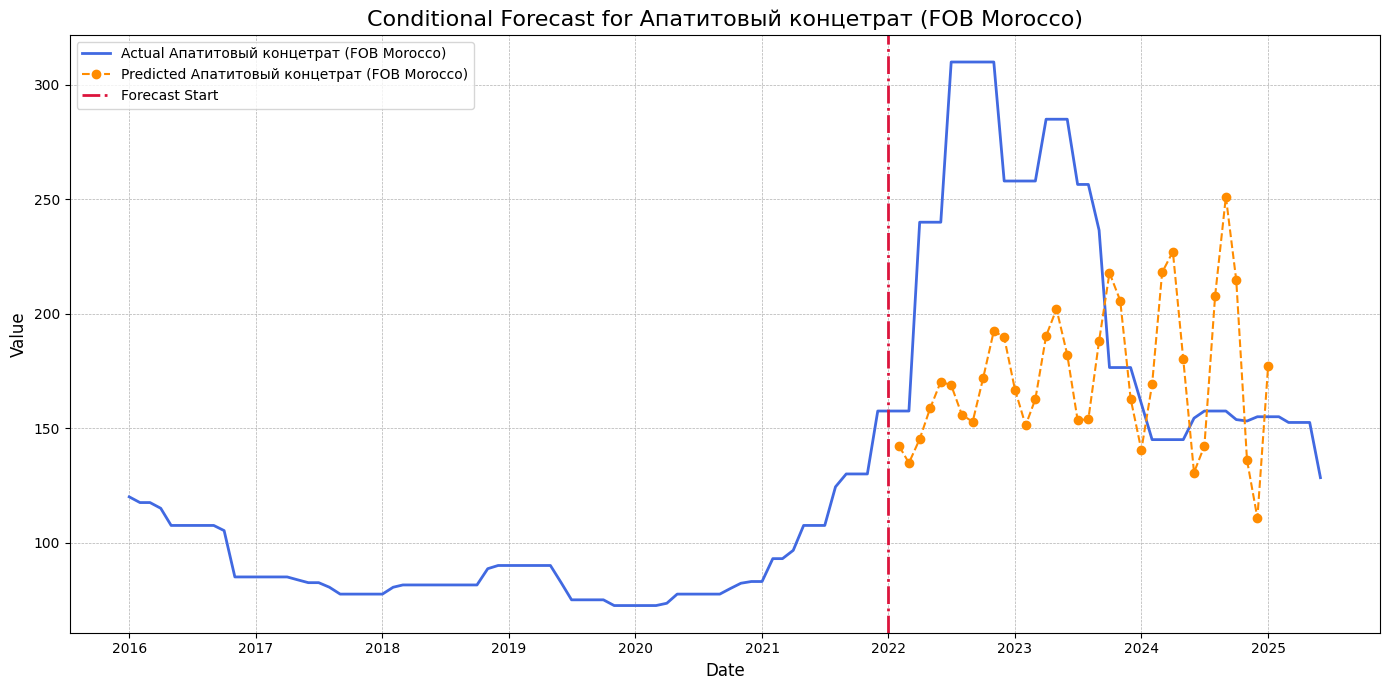

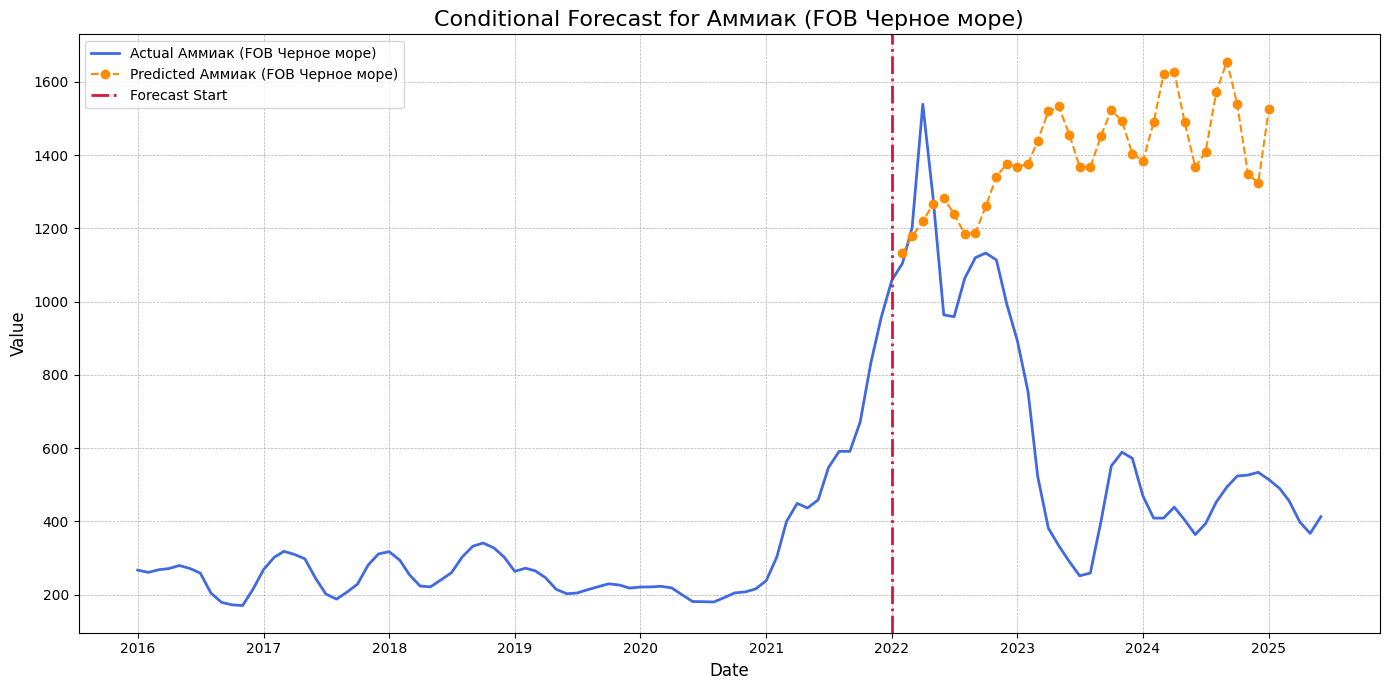

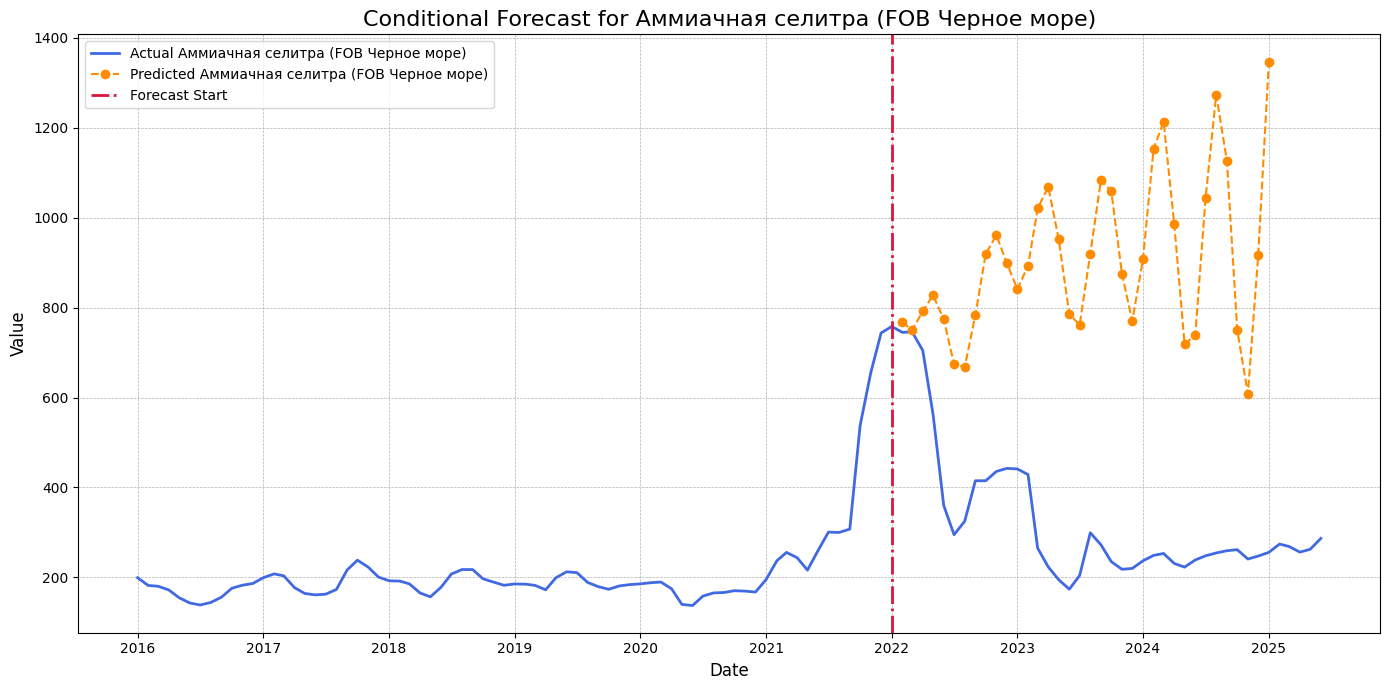

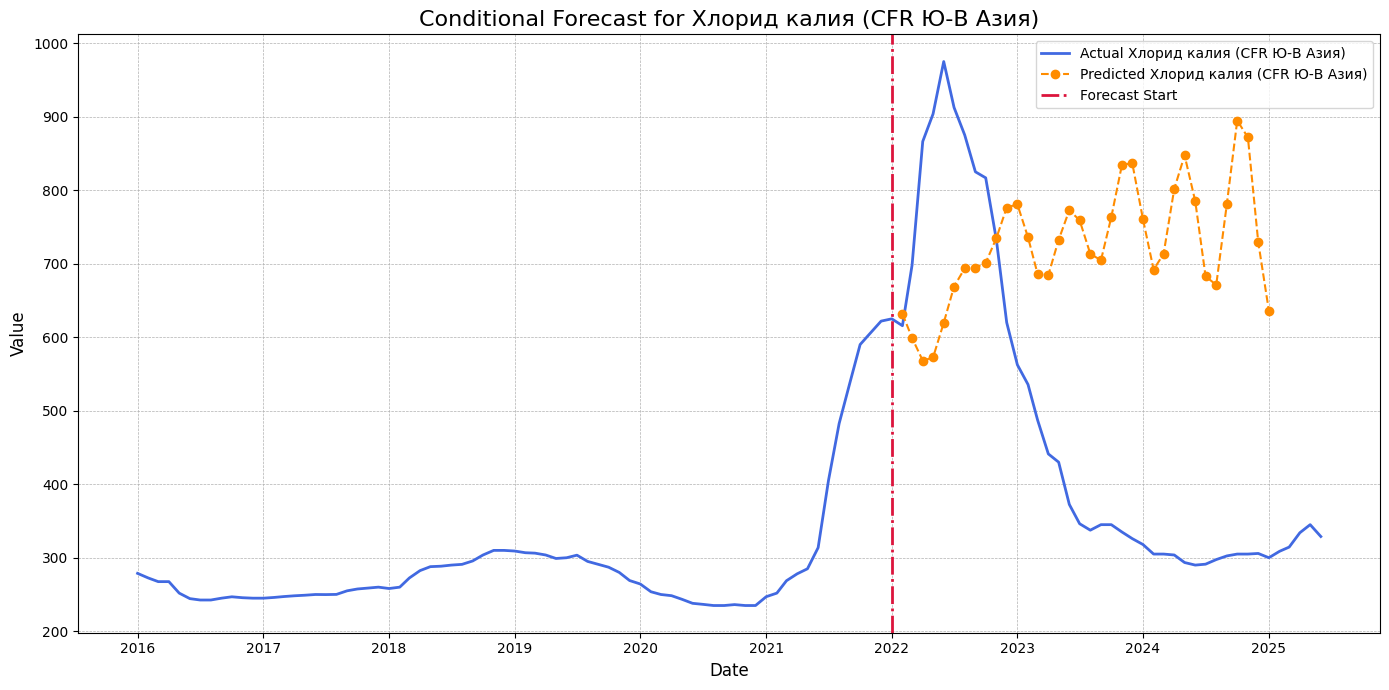

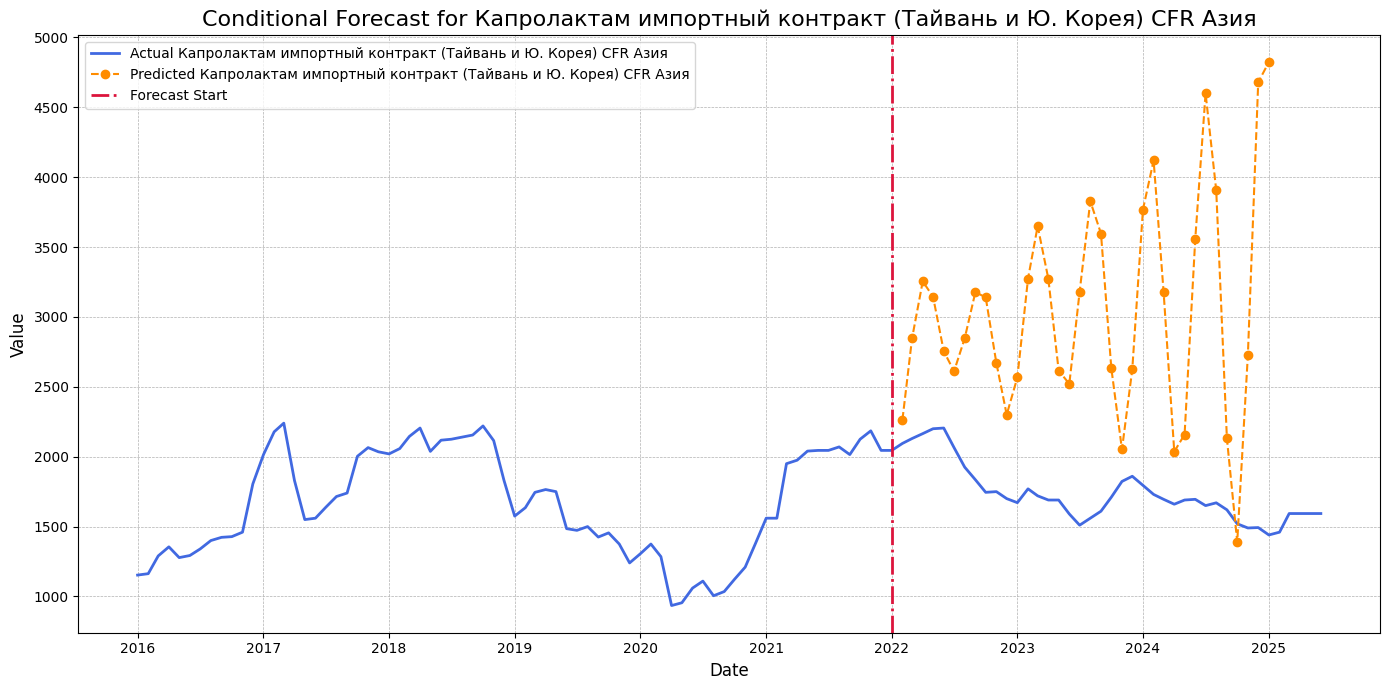

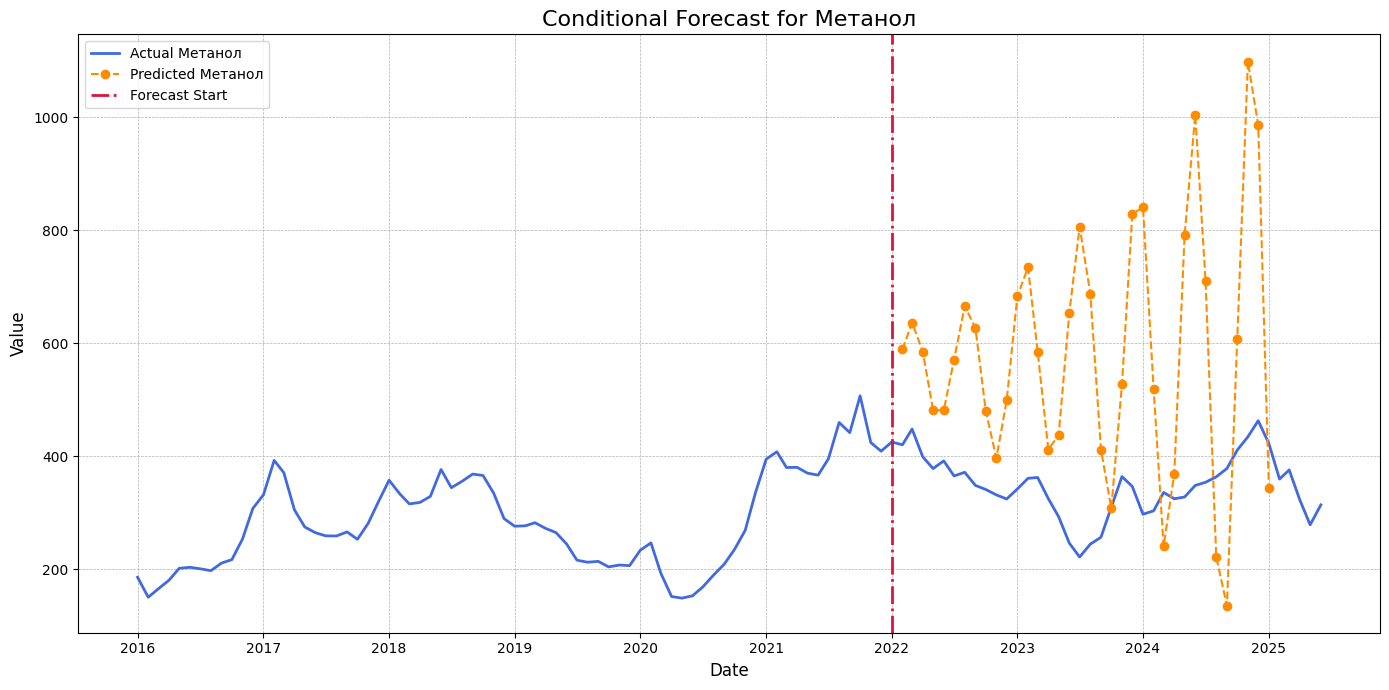

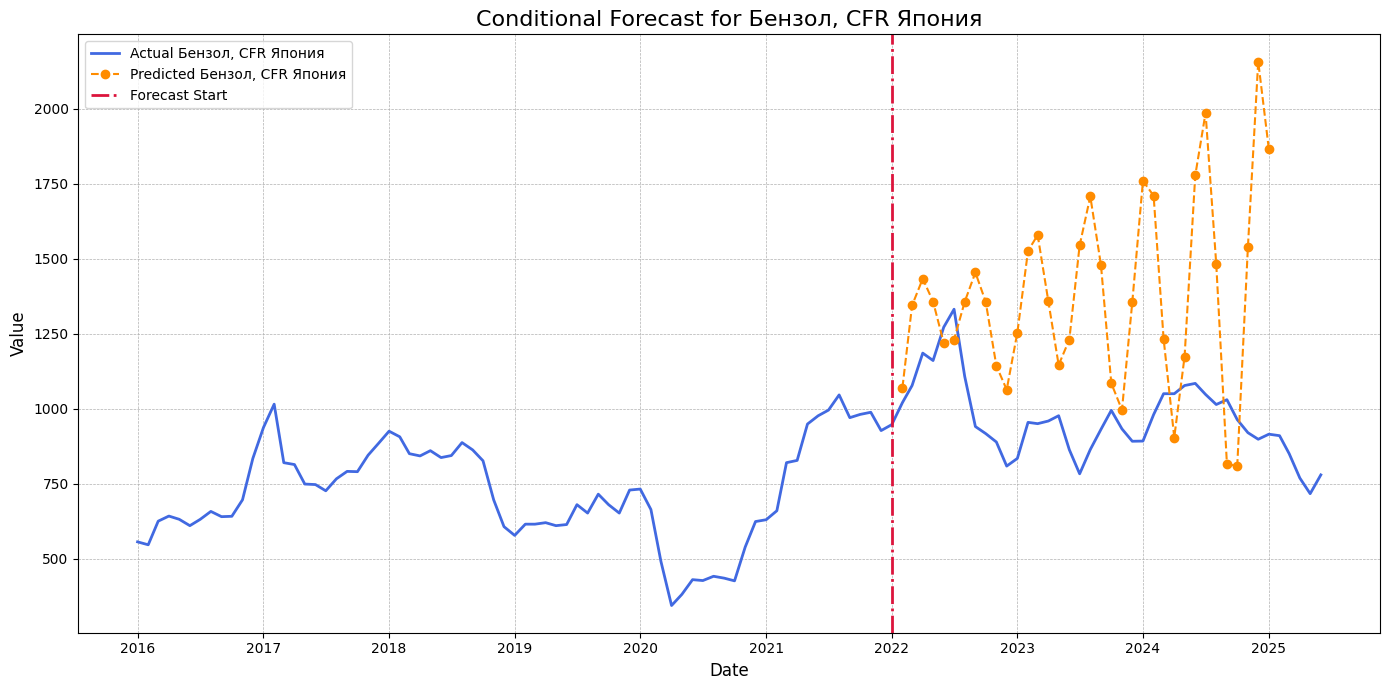

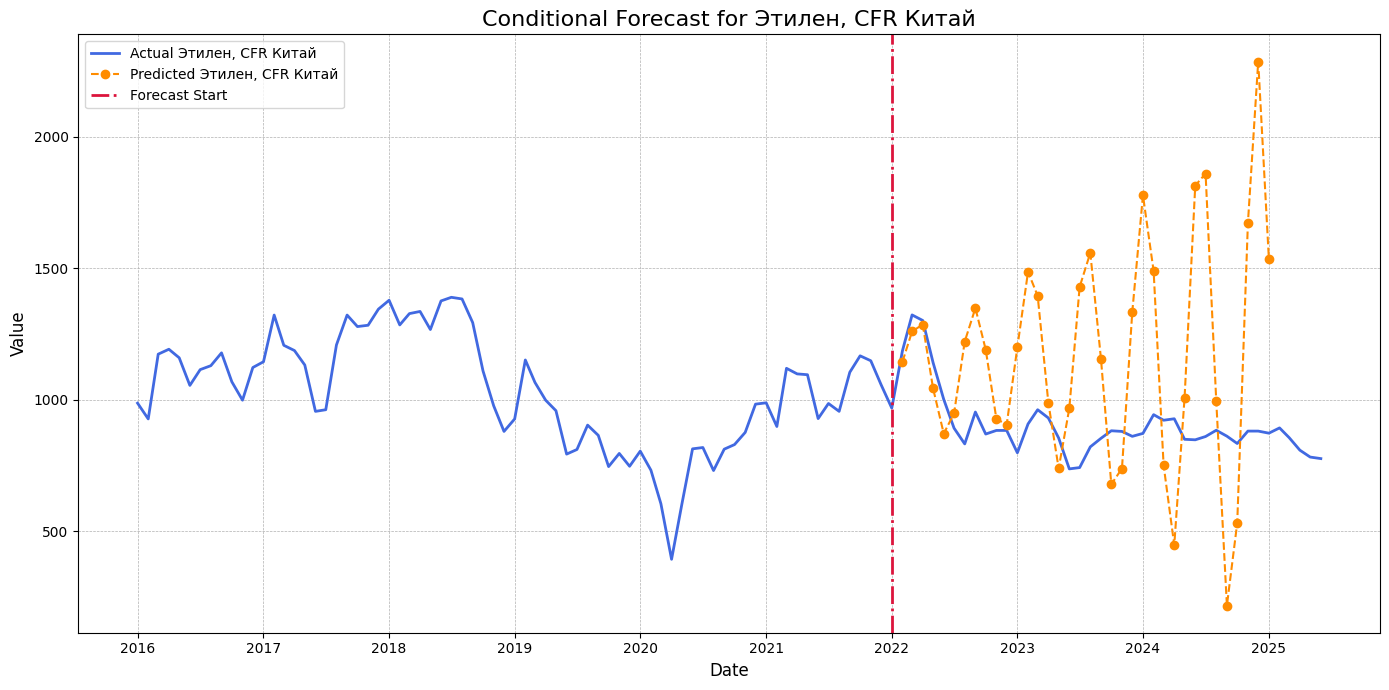

In [22]:
plot_model_pred(
    model_class=SimpleVECM,
    df=df,
    model_params={
        "k_ar_diff": 2,
        "coint_rank": 1,
        "deterministic": "ci",
        "freq": "MS",
    },
    conditioning_col=df.columns[3],
    horizon=36,
    cutoff_date="2022-01-01",
)

# APK

На АПК не из коробки не работает тк слишком много признаков и получается почему-то комплексные собственные значения